# METR's agent-horizon data can't tell a one-week ceiling from none

Companion notebook for the article. Run all cells to reproduce every number and the figure. Needs only NumPy and matplotlib.

From [*Math for ML Engineers: From Backprop to RLHF*](https://mikaelyemane.github.io/ml-math-code/) by Mikael Yemane.

## A horizon is the point where a logistic curve crosses one half

In [1]:
import json, os, urllib.request
import numpy as np

URL = ("https://raw.githubusercontent.com/METR/eval-analysis-public/"
       "52cb829c7a2efb2d659285c4b1768d191d97f8d2/reports/time-horizon-1-1/data/raw/runs.jsonl")
if not os.path.exists("metr_runs.jsonl"):           # 15 MB, METR's public TH1.1 runs
    urllib.request.urlretrieve(URL, "metr_runs.jsonl")
runs = [json.loads(line) for line in open("metr_runs.jsonl")]

def fit(rs, lam=1e-5):
    """METR's model: weighted logistic regression of success on log2(human minutes)."""
    x = np.log2([r["human_minutes"] for r in rs])
    y = np.array([r["score_binarized"] for r in rs], float)
    w = np.array([r["invsqrt_task_weight"] for r in rs]); w /= w.sum()
    X, th = np.c_[np.ones_like(x), x], np.zeros(2)
    for _ in range(50):                               # Newton steps
        p = 1 / (1 + np.exp(-X @ th))
        H = (X * (w * p * (1 - p))[:, None]).T @ X + lam * np.diag([0, 1])
        th -= np.linalg.solve(H, X.T @ (w * (p - y)) + lam * np.r_[0, th[1]])
    a, b = th
    return 2 ** (-a / b), 2 ** ((np.log(4) - a) / b)  # 50% and 80% horizons, minutes

opus = [r for r in runs if r["alias"] == "Claude Opus 4.6 (Inspect)"]
h50, h80 = fit(opus)
tasks = {r["task_id"]: r for r in opus}
mins = np.array([t["human_minutes"] for t in tasks.values()])
print(f"Opus 4.6: 50% horizon {h50/60:.1f} h, 80% horizon {h80:.0f} min, ratio {h50/h80:.1f}")
print(f"tasks {len(tasks)}, longer than the 50% horizon {(mins > h50).sum()}, "
      f"16 h or longer {(mins >= 960).sum()}, longest {mins.max()/60:.0f} h")
long = [t for t in tasks.values() if t["human_minutes"] >= 480]
print(f"8 h+ tasks {len(long)}, human-timed {sum(t['human_source'] == 'baseline' for t in long)}")

flipped, dropped = {}, []                             # one long task's six runs inverted, or removed
for tid in (t["task_id"] for t in long):
    flipped[tid] = fit([dict(r, score_binarized=1 - r["score_binarized"])
                        if r["task_id"] == tid else r for r in opus])[0] / 60
    dropped.append(fit([r for r in opus if r["task_id"] != tid])[0] / 60)
lo, hi = min(flipped, key=flipped.get), max(flipped, key=flipped.get)
print(f"flip one 8 h+ task: {flipped[lo]:.1f} h ({lo}) to {flipped[hi]:.1f} h ({hi}); "
      f"drop one: {min(dropped):.1f} to {max(dropped):.1f} h")

Opus 4.6: 50% horizon 12.0 h, 80% horizon 70 min, ratio 10.3
tasks 228, longer than the 50% horizon 9, 16 h or longer 5, longest 30 h
8 h+ tasks 31, human-timed 5
flip one 8 h+ task: 9.6 h (robot_control/default) to 15.1 h (lie_detector/default); drop one: 10.3 to 13.2 h


## The trend line depends on its start date

In [2]:
from datetime import date, timedelta

def yr(d):                                            # years since 2024-01-01
    return (date.fromisoformat(d) - date(2024, 1, 1)).days / 365.25

released = {"GPT-4 0314": "2023-03-14", "GPT-4 1106 (Inspect)": "2023-11-06",
            "GPT-4o (Inspect)": "2024-05-13", "Claude 3.5 Sonnet (Old) (Inspect)": "2024-06-20",
            "o1-preview": "2024-09-12", "Claude 3.5 Sonnet (New) (Inspect)": "2024-10-22",
            "o1 (Inspect)": "2024-12-05", "Claude 3.7 Sonnet (Inspect)": "2025-02-24",
            "o3 (Inspect)": "2025-04-16", "GPT-5 (Inspect)": "2025-08-07",
            "Gemini 3 Pro": "2025-11-18", "Claude Opus 4.5 (Inspect)": "2025-11-24",
            "GPT-5.2": "2025-12-11", "Claude Opus 4.6 (Inspect)": "2026-02-05"}
model_runs = {m: [r for r in runs if r["alias"] == m] for m in released}   # each set a record
T = np.array([yr(d) for d in released.values()])
Y = np.log2([fit(rs)[0] for rs in model_runs.values()])                    # log2 minutes

cutoffs = [f"{2024 + (m + 11) // 12}-{(m + 11) % 12 + 1:02d}-01" for m in range(12)]  # Dec 24-Nov 25
for start in ("2023-01-01", "2024-05-01"):
    medians = []
    for cut in cutoffs:                               # fit before the cutoff, score the rest
        train, test = (T >= yr(start)) & (T < yr(cut)), T >= yr(cut)
        b0, a0 = np.polyfit(T[train], Y[train], 1)
        medians.append(np.median(2 ** (Y - a0 - b0 * T)[test]))
    print(f"trend fit from {start[:7]}: median actual/forecast across 12 cutoffs "
          f"{min(medians):.2f} to {max(medians):.2f}, over-forecast at {sum(m < 1 for m in medians)}")
for lo, hi in (("2024-05-01", "2025-01-01"), ("2025-01-01", "2026-01-01")):
    span = (T >= yr(lo)) & (T < yr(hi))
    print(f"records {lo[:7]} to {hi[:7]}: doubling every {365.25 / np.polyfit(T[span], Y[span], 1)[0]:.0f} days")

trend fit from 2023-01: median actual/forecast across 12 cutoffs 1.44 to 4.56, over-forecast at 0
trend fit from 2024-05: median actual/forecast across 12 cutoffs 0.53 to 1.18, over-forecast at 11
records 2024-05 to 2025-01: doubling every 93 days
records 2025-01 to 2026-01: doubling every 139 days


## Whether there is a ceiling depends on the weights

In [3]:
def task_table(rs):
    """Collapse runs to tasks: log2 minutes, total weight, weighted successes (same fit)."""
    by = {}
    for r in rs:
        x, w, s = by.get(r["task_id"], (np.log2(r["human_minutes"]), 0.0, 0.0))
        by[r["task_id"]] = (x, w + r["invsqrt_task_weight"], s + r["invsqrt_task_weight"] * r["score_binarized"])
    return np.array(list(by.values()))

def log2_h50(tabs, lam=1e-5):
    """Newton on stacked task tables, shape (draws, tasks, 3); one 2x2 solve per draw."""
    x, w = tabs[..., 0], tabs[..., 1] / tabs[..., 1].sum(-1, keepdims=True)
    ys = tabs[..., 2] / tabs[..., 1].sum(-1, keepdims=True)
    a, b = np.zeros(len(tabs)), np.zeros(len(tabs))
    for _ in range(30):
        p = 1 / (1 + np.exp(-(a[:, None] + b[:, None] * x)))
        v = w * p * (1 - p)
        g0, g1 = (w * p - ys).sum(-1), ((w * p - ys) * x).sum(-1) + lam * b
        h00, h01, h11 = v.sum(-1), (v * x).sum(-1), (v * x * x).sum(-1) + lam
        det = h00 * h11 - h01 ** 2
        a, b = a - (h11 * g0 - h01 * g1) / det, b - (h00 * g1 - h01 * g0) / det
    return -a / b

recent = [m for m, d in released.items() if d >= "2024-05-01"]
tables = [task_table(model_runs[m]) for m in recent]
t, y = T[-len(recent):], np.array([log2_h50(tb[None])[0] for tb in tables])

def sigmas(seed, draws=200):                          # bootstrap over tasks
    rng = np.random.default_rng(seed)
    return np.array([log2_h50(tb[rng.integers(0, len(tb), (draws, len(tb)))]).std() for tb in tables])
sigma = sigmas(0); w = 1 / sigma ** 2
print(f"bootstrap sd of log2 horizon: {sigma.min():.2f} to {sigma.max():.2f} doublings (Opus 4.6 {sigma[-1]:.2f})")

bootstrap sd of log2 horizon: 0.26 to 0.87 doublings (Opus 4.6 0.87)


In [4]:
def fit_curve(cap_hours, weights, keep=slice(None)):
    """log2 h = a + b t (cap None) or K - c exp(-r t); returns (weighted misfit, predictor)."""
    tt, yy, ww = t[keep], y[keep], weights[keep]
    if cap_hours is None:
        A = np.c_[np.ones_like(tt), tt] * np.sqrt(ww)[:, None]
        a, b = np.linalg.lstsq(A, yy * np.sqrt(ww), rcond=None)[0]
        return (ww * (yy - a - b * tt) ** 2).sum(), lambda s: a + b * s
    K, rates = np.log2(cap_hours * 60), np.linspace(0.01, 5, 2000)
    E = np.exp(-rates[:, None] * tt)                  # one row per decay rate r
    c = (E * ww) @ (K - yy) / ((E * ww) * E).sum(1)   # best c in closed form for each r
    sse = (ww * (yy - K + c[:, None] * E) ** 2).sum(1)
    i = sse.argmin()
    return sse[i], lambda s, c=c[i], r=rates[i]: K - c * np.exp(-r * s)

def chi2_sf_10(x):                                    # P(chi2 with 10 dof > x), closed form
    return np.exp(-x / 2) * sum((x / 2) ** k / np.prod(range(1, k + 1)) for k in range(5))

mythos, july28 = yr("2026-03-15"), yr("2028-07-01")
for name, weights in (("unweighted", np.ones_like(w)), ("weighted by 1/sd^2", w)):
    print(name)
    for cap in (None, 24, 168, 8760):
        sse, f = fit_curve(cap, weights)
        print(f"  {'no ceiling' if cap is None else f'ceiling {cap} h':>14}: misfit {sse:5.2f}, "
              f"Mar 2026 {2 ** f(mythos) / 60:4.1f} h, Jul 2028 {2 ** f(july28) / 60:6,.0f} h")
from math import erfc
line, week = fit_curve(None, w), fit_curve(168, w)
gap = line[0] - week[0]                               # one-week ceiling vs line, weighted
print(f"weighted line: chi-squared p = {chi2_sf_10(line[0]):.2f} on 10 dof; one-week ceiling "
      f"improves it by {gap:.2f} (p = {erfc((gap / 2) ** 0.5):.2f} if K counts as one parameter); "
      f"July 2028 forecasts differ {2 ** (line[1](july28) - week[1](july28)):.0f}-fold")
caps = np.logspace(1.2, 6, 97)
for seed in (0, 1, 2):
    ws = 1 / sigmas(seed) ** 2
    print(f"seed {seed}: best weighted ceiling {min((fit_curve(h, ws)[0], h) for h in caps)[1]:,.0f} h")
print(f"unweighted best ceiling {min((fit_curve(h, np.ones_like(w))[0], h) for h in caps)[1]:,.0f} h; "
      f"without Opus 4.6, one-week ceiling misfit {fit_curve(168, np.ones_like(w), slice(-1))[0]:.2f} "
      f"vs line {fit_curve(None, np.ones_like(w), slice(-1))[0]:.2f}")

unweighted
      no ceiling: misfit  1.17, Mar 2026 12.2 h, Jul 2028  3,140 h
    ceiling 24 h: misfit  1.79, Mar 2026  7.0 h, Jul 2028     20 h
   ceiling 168 h: misfit  1.15, Mar 2026  8.8 h, Jul 2028     65 h
  ceiling 8760 h: misfit  1.01, Mar 2026 10.3 h, Jul 2028    241 h
weighted by 1/sd^2
      no ceiling: misfit 11.94, Mar 2026 11.7 h, Jul 2028  2,733 h
    ceiling 24 h: misfit  8.79, Mar 2026  6.3 h, Jul 2028     19 h
   ceiling 168 h: misfit  7.08, Mar 2026  8.0 h, Jul 2028     60 h
  ceiling 8760 h: misfit  8.08, Mar 2026  9.6 h, Jul 2028    219 h
weighted line: chi-squared p = 0.29 on 10 dof; one-week ceiling improves it by 4.86 (p = 0.03 if K counts as one parameter); July 2028 forecasts differ 45-fold


seed 0: best weighted ceiling 141 h


seed 1: best weighted ceiling 158 h


seed 2: best weighted ceiling 251 h
unweighted best ceiling 14,125 h; without Opus 4.6, one-week ceiling misfit 0.59 vs line 1.01


## The figure

In [5]:
#@title Shared figure style (run this cell; the code can stay hidden)
"""Shared figure style for the article series.

Static PNGs for Medium/Substack (light page), 1600 x 900 px at 200 dpi.
Palette: validated categorical slots 1-3 (all-pairs pass, light mode).
Slot 3 (aqua) is below 3:1 contrast on the surface, so every series is
direct-labeled; identity never rests on color alone.
"""
import matplotlib

import matplotlib.pyplot as plt  # noqa: E402

SURFACE = "#ffffff"
INK = "#0b0b0b"          # primary text
INK_2 = "#52514e"        # secondary text, axis labels
MUTED = "#8a8985"        # tick labels, annotations
GRID = "#e8e7e3"         # recessive grid
NEUTRAL = "#b9b8b3"      # de-emphasized series / reference lines

S1, S2, S3 = "#2a78d6", "#eb6834", "#1baf7a"   # blue, orange, aqua
SERIES = [S1, S2, S3]

FIG_W, FIG_H, DPI = 8.0, 4.5, 200


def setup():
    plt.rcParams.update({
        "figure.facecolor": SURFACE,
        "axes.facecolor": SURFACE,
        "savefig.facecolor": SURFACE,
        "font.size": 11,
        "font.family": "DejaVu Sans",
        "axes.edgecolor": GRID,
        "axes.labelcolor": INK_2,
        "axes.labelsize": 11,
        "axes.titlesize": 13,
        "axes.titleweight": "bold",
        "axes.titlecolor": INK,
        "axes.titlelocation": "left",
        "axes.titlepad": 22,
        "axes.spines.top": False,
        "axes.spines.right": False,
        "axes.grid": True,
        "grid.color": GRID,
        "grid.linewidth": 0.8,
        "xtick.color": MUTED,
        "ytick.color": MUTED,
        "xtick.labelcolor": INK_2,
        "ytick.labelcolor": INK_2,
        "lines.linewidth": 2.0,
        "lines.markersize": 6,
        "legend.frameon": False,
        "legend.fontsize": 10,
        "legend.labelcolor": INK_2,
    })


def fig(nrows=1, ncols=1, **kw):
    setup()
    return plt.subplots(nrows, ncols, figsize=(FIG_W, FIG_H), dpi=DPI, **kw)


def subtitle(ax, text):
    """Units / one-line context under the title, in secondary ink."""
    ax.text(0, 1.02, text, transform=ax.transAxes, color=INK_2,
            fontsize=10, va="bottom", ha="left")


def label_end(ax, x, y, text, color, dx=4, dy=0):
    """Direct label at a line's end, in text ink with a color key dot."""
    ax.annotate(text, (x, y), xytext=(dx, dy), textcoords="offset points",
                color=INK, fontsize=10, va="center", ha="left")


def save(f, path):
    f.tight_layout()
    f.savefig(path, dpi=DPI)
    print("wrote", path)

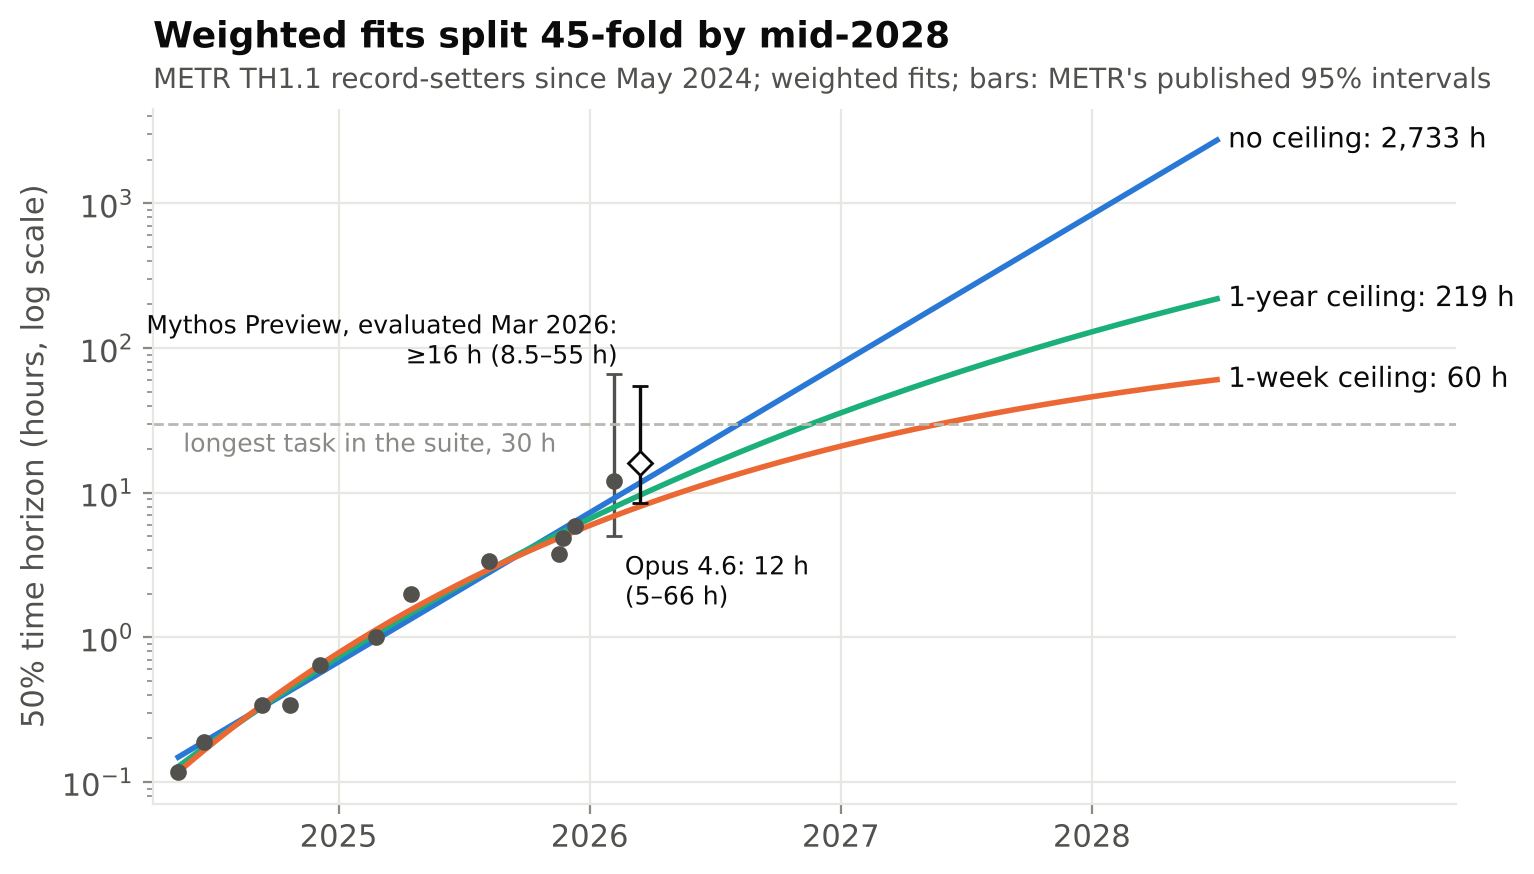

In [6]:
#@title The figure
import contextlib, io
__file__ = 'figure.py'  # the PNG is saved next to the notebook
ARTICLE_MD = '```python\nimport json, os, urllib.request\nimport numpy as np\n\nURL = ("https://raw.githubusercontent.com/METR/eval-analysis-public/"\n       "52cb829c7a2efb2d659285c4b1768d191d97f8d2/reports/time-horizon-1-1/data/raw/runs.jsonl")\nif not os.path.exists("metr_runs.jsonl"):           # 15 MB, METR\'s public TH1.1 runs\n    urllib.request.urlretrieve(URL, "metr_runs.jsonl")\nruns = [json.loads(line) for line in open("metr_runs.jsonl")]\n\ndef fit(rs, lam=1e-5):\n    """METR\'s model: weighted logistic regression of success on log2(human minutes)."""\n    x = np.log2([r["human_minutes"] for r in rs])\n    y = np.array([r["score_binarized"] for r in rs], float)\n    w = np.array([r["invsqrt_task_weight"] for r in rs]); w /= w.sum()\n    X, th = np.c_[np.ones_like(x), x], np.zeros(2)\n    for _ in range(50):                               # Newton steps\n        p = 1 / (1 + np.exp(-X @ th))\n        H = (X * (w * p * (1 - p))[:, None]).T @ X + lam * np.diag([0, 1])\n        th -= np.linalg.solve(H, X.T @ (w * (p - y)) + lam * np.r_[0, th[1]])\n    a, b = th\n    return 2 ** (-a / b), 2 ** ((np.log(4) - a) / b)  # 50% and 80% horizons, minutes\n\nopus = [r for r in runs if r["alias"] == "Claude Opus 4.6 (Inspect)"]\nh50, h80 = fit(opus)\ntasks = {r["task_id"]: r for r in opus}\nmins = np.array([t["human_minutes"] for t in tasks.values()])\nprint(f"Opus 4.6: 50% horizon {h50/60:.1f} h, 80% horizon {h80:.0f} min, ratio {h50/h80:.1f}")\nprint(f"tasks {len(tasks)}, longer than the 50% horizon {(mins > h50).sum()}, "\n      f"16 h or longer {(mins >= 960).sum()}, longest {mins.max()/60:.0f} h")\nlong = [t for t in tasks.values() if t["human_minutes"] >= 480]\nprint(f"8 h+ tasks {len(long)}, human-timed {sum(t[\'human_source\'] == \'baseline\' for t in long)}")\n\nflipped, dropped = {}, []                             # one long task\'s six runs inverted, or removed\nfor tid in (t["task_id"] for t in long):\n    flipped[tid] = fit([dict(r, score_binarized=1 - r["score_binarized"])\n                        if r["task_id"] == tid else r for r in opus])[0] / 60\n    dropped.append(fit([r for r in opus if r["task_id"] != tid])[0] / 60)\nlo, hi = min(flipped, key=flipped.get), max(flipped, key=flipped.get)\nprint(f"flip one 8 h+ task: {flipped[lo]:.1f} h ({lo}) to {flipped[hi]:.1f} h ({hi}); "\n      f"drop one: {min(dropped):.1f} to {max(dropped):.1f} h")\n```\n```python\nfrom datetime import date, timedelta\n\ndef yr(d):                                            # years since 2024-01-01\n    return (date.fromisoformat(d) - date(2024, 1, 1)).days / 365.25\n\nreleased = {"GPT-4 0314": "2023-03-14", "GPT-4 1106 (Inspect)": "2023-11-06",\n            "GPT-4o (Inspect)": "2024-05-13", "Claude 3.5 Sonnet (Old) (Inspect)": "2024-06-20",\n            "o1-preview": "2024-09-12", "Claude 3.5 Sonnet (New) (Inspect)": "2024-10-22",\n            "o1 (Inspect)": "2024-12-05", "Claude 3.7 Sonnet (Inspect)": "2025-02-24",\n            "o3 (Inspect)": "2025-04-16", "GPT-5 (Inspect)": "2025-08-07",\n            "Gemini 3 Pro": "2025-11-18", "Claude Opus 4.5 (Inspect)": "2025-11-24",\n            "GPT-5.2": "2025-12-11", "Claude Opus 4.6 (Inspect)": "2026-02-05"}\nmodel_runs = {m: [r for r in runs if r["alias"] == m] for m in released}   # each set a record\nT = np.array([yr(d) for d in released.values()])\nY = np.log2([fit(rs)[0] for rs in model_runs.values()])                    # log2 minutes\n\ncutoffs = [f"{2024 + (m + 11) // 12}-{(m + 11) % 12 + 1:02d}-01" for m in range(12)]  # Dec 24-Nov 25\nfor start in ("2023-01-01", "2024-05-01"):\n    medians = []\n    for cut in cutoffs:                               # fit before the cutoff, score the rest\n        train, test = (T >= yr(start)) & (T < yr(cut)), T >= yr(cut)\n        b0, a0 = np.polyfit(T[train], Y[train], 1)\n        medians.append(np.median(2 ** (Y - a0 - b0 * T)[test]))\n    print(f"trend fit from {start[:7]}: median actual/forecast across 12 cutoffs "\n          f"{min(medians):.2f} to {max(medians):.2f}, over-forecast at {sum(m < 1 for m in medians)}")\nfor lo, hi in (("2024-05-01", "2025-01-01"), ("2025-01-01", "2026-01-01")):\n    span = (T >= yr(lo)) & (T < yr(hi))\n    print(f"records {lo[:7]} to {hi[:7]}: doubling every {365.25 / np.polyfit(T[span], Y[span], 1)[0]:.0f} days")\n```\n```python\ndef task_table(rs):\n    """Collapse runs to tasks: log2 minutes, total weight, weighted successes (same fit)."""\n    by = {}\n    for r in rs:\n        x, w, s = by.get(r["task_id"], (np.log2(r["human_minutes"]), 0.0, 0.0))\n        by[r["task_id"]] = (x, w + r["invsqrt_task_weight"], s + r["invsqrt_task_weight"] * r["score_binarized"])\n    return np.array(list(by.values()))\n\ndef log2_h50(tabs, lam=1e-5):\n    """Newton on stacked task tables, shape (draws, tasks, 3); one 2x2 solve per draw."""\n    x, w = tabs[..., 0], tabs[..., 1] / tabs[..., 1].sum(-1, keepdims=True)\n    ys = tabs[..., 2] / tabs[..., 1].sum(-1, keepdims=True)\n    a, b = np.zeros(len(tabs)), np.zeros(len(tabs))\n    for _ in range(30):\n        p = 1 / (1 + np.exp(-(a[:, None] + b[:, None] * x)))\n        v = w * p * (1 - p)\n        g0, g1 = (w * p - ys).sum(-1), ((w * p - ys) * x).sum(-1) + lam * b\n        h00, h01, h11 = v.sum(-1), (v * x).sum(-1), (v * x * x).sum(-1) + lam\n        det = h00 * h11 - h01 ** 2\n        a, b = a - (h11 * g0 - h01 * g1) / det, b - (h00 * g1 - h01 * g0) / det\n    return -a / b\n\nrecent = [m for m, d in released.items() if d >= "2024-05-01"]\ntables = [task_table(model_runs[m]) for m in recent]\nt, y = T[-len(recent):], np.array([log2_h50(tb[None])[0] for tb in tables])\n\ndef sigmas(seed, draws=200):                          # bootstrap over tasks\n    rng = np.random.default_rng(seed)\n    return np.array([log2_h50(tb[rng.integers(0, len(tb), (draws, len(tb)))]).std() for tb in tables])\nsigma = sigmas(0); w = 1 / sigma ** 2\nprint(f"bootstrap sd of log2 horizon: {sigma.min():.2f} to {sigma.max():.2f} doublings (Opus 4.6 {sigma[-1]:.2f})")\n```\n```python\ndef fit_curve(cap_hours, weights, keep=slice(None)):\n    """log2 h = a + b t (cap None) or K - c exp(-r t); returns (weighted misfit, predictor)."""\n    tt, yy, ww = t[keep], y[keep], weights[keep]\n    if cap_hours is None:\n        A = np.c_[np.ones_like(tt), tt] * np.sqrt(ww)[:, None]\n        a, b = np.linalg.lstsq(A, yy * np.sqrt(ww), rcond=None)[0]\n        return (ww * (yy - a - b * tt) ** 2).sum(), lambda s: a + b * s\n    K, rates = np.log2(cap_hours * 60), np.linspace(0.01, 5, 2000)\n    E = np.exp(-rates[:, None] * tt)                  # one row per decay rate r\n    c = (E * ww) @ (K - yy) / ((E * ww) * E).sum(1)   # best c in closed form for each r\n    sse = (ww * (yy - K + c[:, None] * E) ** 2).sum(1)\n    i = sse.argmin()\n    return sse[i], lambda s, c=c[i], r=rates[i]: K - c * np.exp(-r * s)\n\ndef chi2_sf_10(x):                                    # P(chi2 with 10 dof > x), closed form\n    return np.exp(-x / 2) * sum((x / 2) ** k / np.prod(range(1, k + 1)) for k in range(5))\n\nmythos, july28 = yr("2026-03-15"), yr("2028-07-01")\nfor name, weights in (("unweighted", np.ones_like(w)), ("weighted by 1/sd^2", w)):\n    print(name)\n    for cap in (None, 24, 168, 8760):\n        sse, f = fit_curve(cap, weights)\n        print(f"  {\'no ceiling\' if cap is None else f\'ceiling {cap} h\':>14}: misfit {sse:5.2f}, "\n              f"Mar 2026 {2 ** f(mythos) / 60:4.1f} h, Jul 2028 {2 ** f(july28) / 60:6,.0f} h")\nfrom math import erfc\nline, week = fit_curve(None, w), fit_curve(168, w)\ngap = line[0] - week[0]                               # one-week ceiling vs line, weighted\nprint(f"weighted line: chi-squared p = {chi2_sf_10(line[0]):.2f} on 10 dof; one-week ceiling "\n      f"improves it by {gap:.2f} (p = {erfc((gap / 2) ** 0.5):.2f} if K counts as one parameter); "\n      f"July 2028 forecasts differ {2 ** (line[1](july28) - week[1](july28)):.0f}-fold")\ncaps = np.logspace(1.2, 6, 97)\nfor seed in (0, 1, 2):\n    ws = 1 / sigmas(seed) ** 2\n    print(f"seed {seed}: best weighted ceiling {min((fit_curve(h, ws)[0], h) for h in caps)[1]:,.0f} h")\nprint(f"unweighted best ceiling {min((fit_curve(h, np.ones_like(w))[0], h) for h in caps)[1]:,.0f} h; "\n      f"without Opus 4.6, one-week ceiling misfit {fit_curve(168, np.ones_like(w), slice(-1))[0]:.2f} "\n      f"vs line {fit_curve(None, np.ones_like(w), slice(-1))[0]:.2f}")\n```'
with contextlib.redirect_stdout(io.StringIO()):  # keep the output to the chart
    import pathlib
    import numpy as np, os, re
    os.chdir(pathlib.Path(__file__).parent)
    # Reuse the article's own code blocks: data, fits, record-setters, weights.
    src = ARTICLE_MD
    exec("\n".join(re.findall(r"```python\n(.*?)```", src, flags=re.S)).replace("print(", "(lambda *a, **k: None)("))

    tt = np.linspace(t.min(), july28, 400)
    f, ax = fig()
    ax.plot(t, 2 ** y / 60, "o", color=INK_2, ms=5, zorder=3)
    lo, hi = 5, 66                                         # METR's published 95% interval
    ax.errorbar([t[-1]], [2 ** y[-1] / 60], yerr=[[2 ** y[-1] / 60 - lo], [hi - 2 ** y[-1] / 60]],
                fmt="none", ecolor=INK_2, elinewidth=1.2, capsize=3, zorder=2)
    for cap, col, name in ((None, S1, "no ceiling"), (8760, S3, "1-year ceiling"), (168, S2, "1-week ceiling")):
        _, fn = fit_curve(cap, w)
        ax.plot(tt, 2 ** fn(tt) / 60, color=col)
        label_end(ax, tt[-1], 2 ** fn(tt[-1]) / 60, f"{name}: {2 ** fn(tt[-1]) / 60:,.0f} h", col)
    ax.annotate("Opus 4.6: 12 h\n(5–66 h)", (t[-1], 5), xytext=(4, -6), textcoords="offset points",
                ha="left", va="top", color=INK, fontsize=9)
    ax.errorbar([mythos], [16], yerr=[[16 - 8.5], [55 - 16]], fmt="D", mfc="white", mec=INK,
                ecolor=INK, ms=6, elinewidth=1.2, capsize=3, zorder=4)
    ax.annotate("Mythos Preview, evaluated Mar 2026:\n≥16 h (8.5–55 h)", (mythos, 55), xytext=(-8, 8),
                textcoords="offset points", ha="right", color=INK, fontsize=9)
    ax.axhline(30, color=NEUTRAL, lw=1, ls="--")
    ax.text(t.min() + 0.02, 26, "longest task in the suite, 30 h", color=MUTED, fontsize=9, va="top")
    ax.set_yscale("log")
    ax.set_xticks([yr(f"{k}-01-01") for k in range(2025, 2029)]); ax.set_xticklabels(range(2025, 2029))
    ax.set_xlim(t.min() - 0.1, tt[-1] + 0.95)
    ax.set_ylabel("50% time horizon (hours, log scale)")
    ax.set_title(f"Weighted fits split {2 ** (line[1](july28) - week[1](july28)):.0f}-fold by mid-2028")
    subtitle(ax, "METR TH1.1 record-setters since May 2024; weighted fits; bars: METR's published 95% intervals")
    save(f, pathlib.Path(__file__).parent / "16-horizon-forecasts.png")
import matplotlib.pyplot as plt
plt.show()